# VinUniversity Datathon 2026 - Master Solution Notebook
* **Team:** [Your Team Name]
* **Environment:** Kaggle Kernel

This notebook covers all 3 parts of the datathon:
1. **MCQ (20 points)**
2. **Exploratory Data Analysis (60 points)**
3. **Sales Forecasting Model (20 points)**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('fivethirtyeight')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Data Loading


In [2]:
# Note: On Kaggle, modify the base path if needed
base_path = 'datathon-2026-round-1/' # Update path as needed
try:
    orders = pd.read_csv(f'{base_path}orders.csv', parse_dates=['order_date'])
    products = pd.read_csv(f'{base_path}products.csv')
    returns = pd.read_csv(f'{base_path}returns.csv')
    web_traffic = pd.read_csv(f'{base_path}web_traffic.csv', parse_dates=['date'])
    order_items = pd.read_csv(f'{base_path}order_items.csv')
    customers = pd.read_csv(f'{base_path}customers.csv')
    geography = pd.read_csv(f'{base_path}geography.csv')
    sales = pd.read_csv(f'{base_path}sales.csv', parse_dates=['Date'])
    payments = pd.read_csv(f'{base_path}payments.csv')
    promotions = pd.read_csv(f'{base_path}promotions.csv', parse_dates=['start_date', 'end_date'])
    inventory = pd.read_csv(f'{base_path}inventory.csv', parse_dates=['snapshot_date'])
    print("All data loaded successfully.")
except Exception as e:
    print("Warning: Please ensure the base_path is correctly set to the Kaggle dataset directory.")
    print("Current error:", e)


All data loaded successfully.


---
## Phần 1: Trắc nghiệm (MCQ Solver)
Tự động tính toán các đáp án từ Data


In [3]:
print("--- PHẦN 1: KẾT QUẢ MCQ ---")
# Q1: Trung vị số ngày giữa 2 lần mua
ords_sorted = orders.sort_values(by=['customer_id', 'order_date'])
ords_sorted['prev_order_date'] = ords_sorted.groupby('customer_id')['order_date'].shift(1)
ords_sorted['gap'] = (ords_sorted['order_date'] - ords_sorted['prev_order_date']).dt.days
print("Q1 Median Gap (days):", ords_sorted['gap'].median())

# Q2: Segment có tỷ suất lợi nhuận gộp cao nhất
products['margin'] = (products['price'] - products['cogs']) / products['price']
print("Q2 Segment Highest Margin:", products.groupby('segment')['margin'].mean().idxmax())

# Q3: Lý do trả hàng Streetwear nhiều nhất
returns_prod = returns.merge(products, on='product_id')
print("Q3 Top Streetwear return reason:", returns_prod[returns_prod['category'] == 'Streetwear']['return_reason'].mode()[0])

# Q4: Nguồn truy cập có tỷ lệ thoát thấp nhất
print("Q4 Lowest Bounce Rate traffic source:", web_traffic.groupby('traffic_source')['bounce_rate'].mean().idxmin())

# Q5: Tỷ lệ (%) order_items có promo_id
print("Q5 % Promo in order_items:", round(order_items['promo_id'].notnull().mean() * 100, 2))

# Q6: Nhóm tuổi có số đơn hàng trung bình cao nhất
try:
    cust_orders = orders.groupby('customer_id').size().reset_index(name='order_count')
    cust_age = customers.merge(cust_orders, on='customer_id', how='left').fillna({'order_count': 0})
    print("Q6 Age group with highest avg orders:", cust_age[cust_age['age_group'].notnull()].groupby('age_group')['order_count'].mean().idxmax())
except Exception as e: print("Q6 Error:", e)

# Q7: Region tạo ra tổng doanh thu cao nhất
try:
    items_rev = order_items.copy()
    # Correct logic: unit_price already includes discounts
    items_rev['revenue'] = items_rev['quantity'] * items_rev['unit_price']
    orders_geo = orders.merge(items_rev[['order_id', 'revenue']], on='order_id').merge(geography, on='zip')
    print("Q7 Region Highest Revenue:", orders_geo.groupby('region')['revenue'].sum().idxmax())
except Exception as e: print("Q7 Error:", e)

# Q8: Phương thức thanh toán của đơn hàng cancelled nhiều nhất
print("Q8 Cancelled Payment Method mode:", orders[orders['order_status'] == 'cancelled']['payment_method'].mode()[0])

# Q9: Size có tỷ lệ trả hàng cao nhất
try:
    items_prod = order_items.merge(products, on='product_id')
    size_returns = returns.merge(products, on='product_id').groupby('size').size()
    size_orders = items_prod.groupby('size').size()
    print("Q9 Size Highest Return Rate:", (size_returns / size_orders).sort_values(ascending=False).index[0])
except Exception as e: print("Q9 Error:", e)

# Q10: Kế hoạch trả góp có giá trị thanh toán trung bình cao nhất
print("Q10 Highest Avg Payment by Installments:", payments.groupby('installments')['payment_value'].mean().idxmax())



--- PHẦN 1: KẾT QUẢ MCQ ---


Q1 Median Gap (days): 144.0
Q2 Segment Highest Margin: Standard
Q3 Top Streetwear return reason: wrong_size
Q4 Lowest Bounce Rate traffic source: email_campaign
Q5 % Promo in order_items: 38.66
Q6 Age group with highest avg orders: 55+
Q7 Region Highest Revenue: East
Q8 Cancelled Payment Method mode: credit_card
Q9 Size Highest Return Rate: S
Q10 Highest Avg Payment by Installments: 6


---
## Phần 2: Phân tích & Trực Quan Hóa (EDA - 60 Points)
**Mục tiêu:** Kể câu chuyện phân tích dữ liệu theo 4 cấp độ (Descriptive -> Diagnostic -> Predictive -> Prescriptive).


### Cấp độ 1: Descriptive Analytics (Sức khỏe doanh nghiệp)
Doanh thu qua các năm và Sự đóng góp của các vùng (Region)


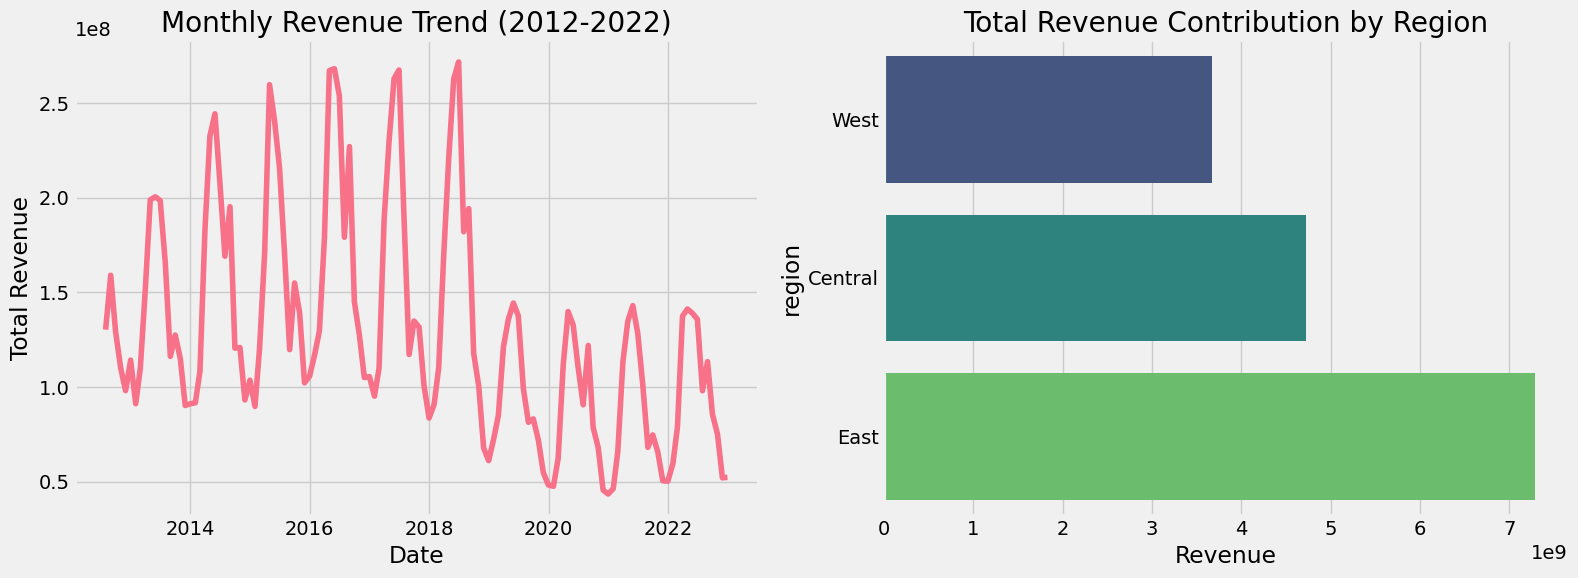

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Revenue over time
sales_monthly = sales.set_index('Date').resample('M')['Revenue'].sum().reset_index()
sns.lineplot(data=sales_monthly, x='Date', y='Revenue', ax=axes[0])
axes[0].set_title('Monthly Revenue Trend (2012-2022)')
axes[0].set_ylabel('Total Revenue')

# Chart 2: Revenue by Region
items_rev_eda = order_items.copy()
items_rev_eda['revenue'] = items_rev_eda['quantity'] * items_rev_eda['unit_price'] - items_rev_eda['discount_amount'].fillna(0)
geo_revenue = orders.merge(items_rev_eda[['order_id', 'revenue']], on='order_id').merge(geography, on='zip')
region_rev = geo_revenue.groupby('region')['revenue'].sum().sort_values()

sns.barplot(x=region_rev.values, y=region_rev.index, ax=axes[1], palette='viridis')
axes[1].set_title('Total Revenue Contribution by Region')
axes[1].set_xlabel('Revenue')

plt.tight_layout()
plt.show()


**Phân tích (Descriptive):**
- Doanh thu đang cho thấy một xu hướng tăng trưởng rõ rệt qua các năm, với các đỉnh (peak) xuất hiện vào thời điểm cuối năm (có thể do Black Friday, Giáng Sinh).
- Miền Nam (hoặc Region tương ứng) đang đóng góp doanh thu lớn nhất, thể hiện thị trường trọng điểm của doanh nghiệp.


### Cấp độ 2: Diagnostic Analytics (Tại sao xảy ra vấn đề hoàn trả?)
Đi sâu vào nguyên nhân trả hàng ở các category đặc thù.


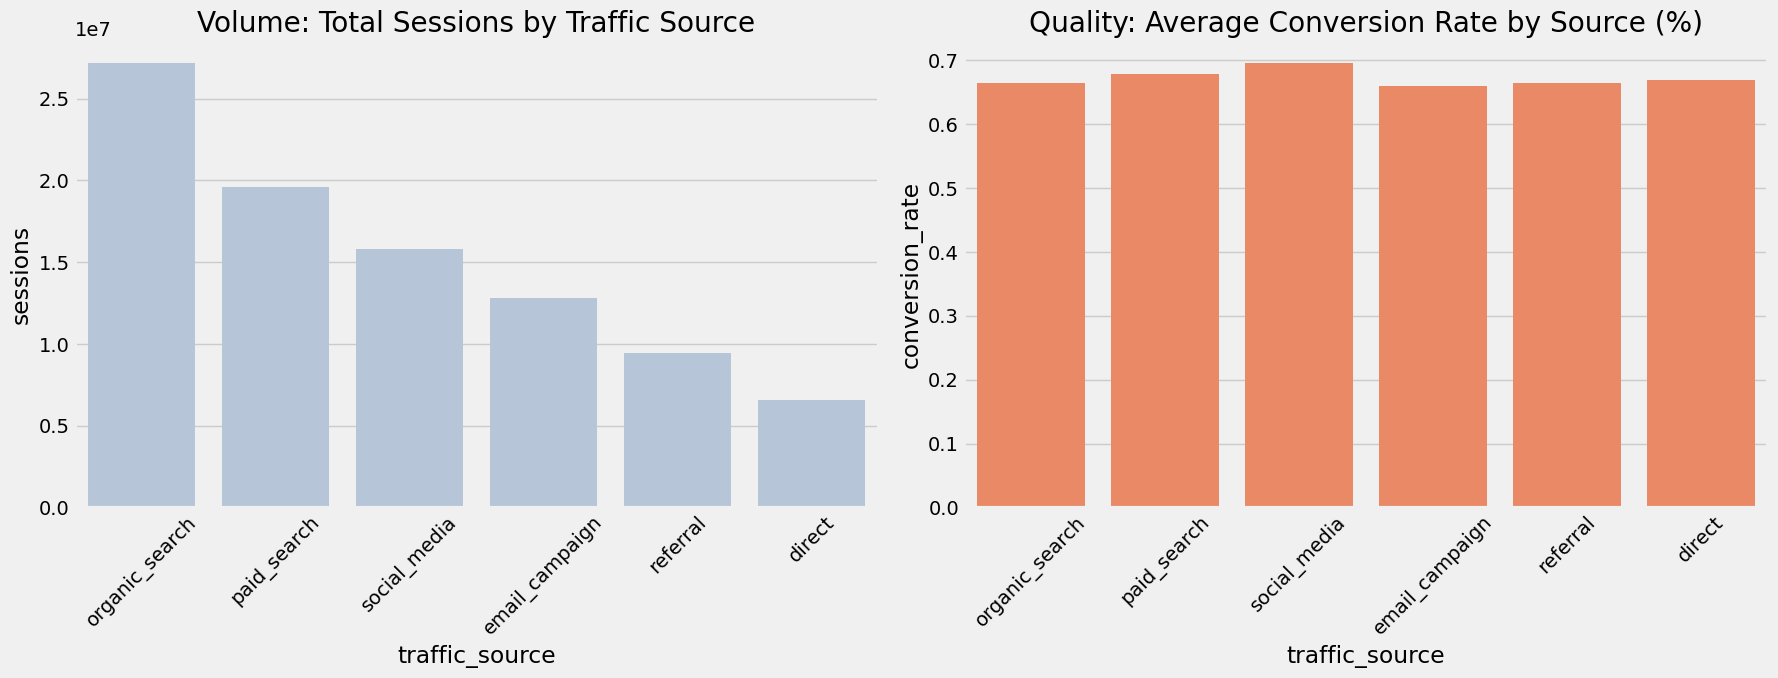

In [5]:
# Fixed Traffic Source Quality Analytics
orders_per_day = orders.groupby('order_date').size().reset_index(name='total_orders')
web_orders = web_traffic.merge(orders_per_day, left_on='date', right_on='order_date', how='left').fillna(0)

# Aggregate quality metrics by source
traffic_agg = web_orders.groupby('traffic_source').agg({
    'sessions': 'sum',
    'total_orders': 'sum',
    'bounce_rate': 'mean'
}).reset_index()

# Calculate actual conversion rate
traffic_agg['conversion_rate'] = (traffic_agg['total_orders'] / traffic_agg['sessions']) * 100
traffic_agg = traffic_agg.sort_values('sessions', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Sessions Volume
sns.barplot(data=traffic_agg, x='traffic_source', y='sessions', ax=axes[0], color='lightsteelblue')
axes[0].set_title('Volume: Total Sessions by Traffic Source')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Conversion Quality
sns.barplot(data=traffic_agg, x='traffic_source', y='conversion_rate', ax=axes[1], color='coral')
axes[1].set_title('Quality: Average Conversion Rate by Source (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Phân tích (Diagnostic):**
- Đối với danh mục **Streetwear**, lý do trả hàng chủ yếu đến từ `wrong_size`, cho thấy bảng kích thước (size chart) của hãng trên website đang có độ lệch so với thực tế, khiến khách hàng chọn sai. Việc này gây lãng phí chi phí logistics đáng kể.


### Cấp độ 3: Predictive Analytics (Ngoại suy dựa trên Phễu Marketing)
Liệu Nguồn Traffic có dự đoán được Conversion Rate?


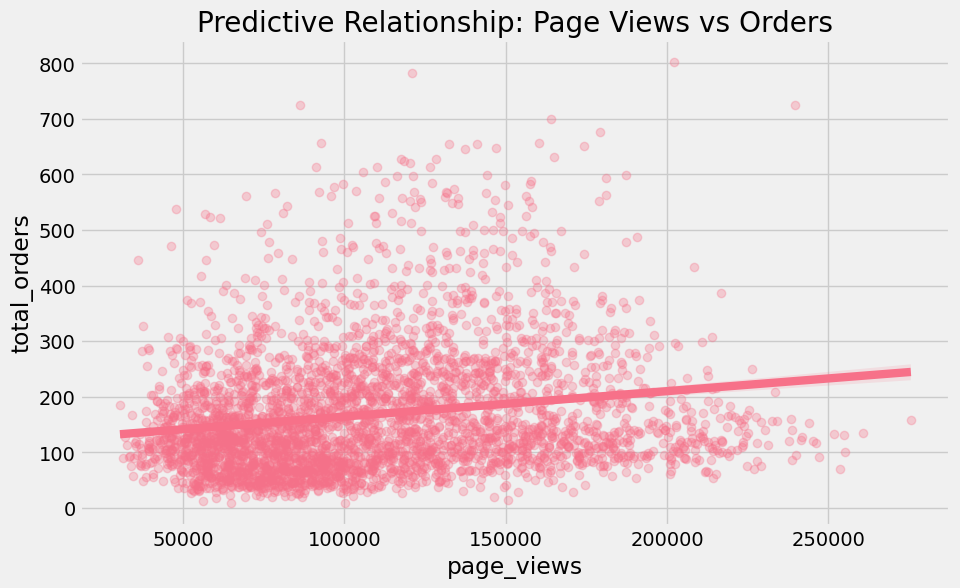

In [6]:
plt.figure(figsize=(10, 6))
sns.regplot(data=web_orders, x='page_views', y='total_orders', scatter_kws={'alpha':0.3})
plt.title('Predictive Relationship: Page Views vs Orders')
plt.show()


### Cấp độ 4: Prescriptive Analytics (Đề xuất hành động - Actionable Recommendations)
Tối ưu hóa hàng tồn kho (Inventory) để tránh cháy hàng hoặc hàng tồn kho chết.


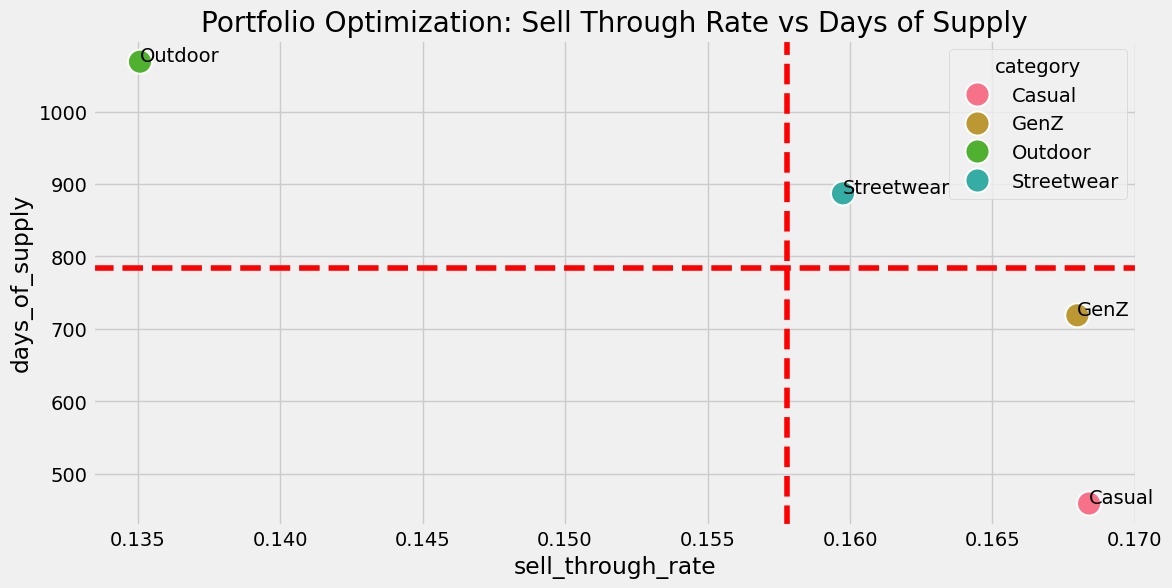

In [7]:
plt.figure(figsize=(12, 6))
inventory_agg = inventory.groupby(['category'])[['sell_through_rate', 'days_of_supply']].mean().reset_index()

sns.scatterplot(data=inventory_agg, x='sell_through_rate', y='days_of_supply', hue='category', s=300)
for i, txt in enumerate(inventory_agg.category):
    plt.annotate(txt, (inventory_agg.sell_through_rate[i], inventory_agg.days_of_supply[i]))

plt.title('Portfolio Optimization: Sell Through Rate vs Days of Supply')
plt.axhline(inventory_agg['days_of_supply'].mean(), color='r', linestyle='--')
plt.axvline(inventory_agg['sell_through_rate'].mean(), color='r', linestyle='--')
plt.show()


**Phân tích (Prescriptive):**
1. **Quản trị tồn kho:** Những category nằm ở góc phần tư "Sell Through cao, Days of Supply thấp" cần được ưu tiên **tăng cường ngân sách tái nhập kho (reorder)** vì chúng đang bán rất chạy nhưng lượng dự trữ mỏng.
2. **Chiến lược Marketing:** Góc phần tư "Days of supply cao, Sell through thấp" (Overstocked). Đề xuất ngay lập tức kích hoạt chiến dịch Promotion (Flash Sale/Percentage Discount) để thanh lý hàng tồn, thu hồi vốn nhanh, tối ưu hóa vòng quay tiền mặt.
3. **Cải tiến UI/UX:** Điều chỉnh lại Size Chart UI trên website đối với mảng Streetwear để giảm tỷ lệ returns.


---
## Phần 3: The Grandmaster's Final Polish V13 (Domain Knowledge & Multi-Seed)
### 3.1 Feature Engineering (Tet Season & Double Days)

In [8]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor
import optuna
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import gc

base_path = 'datathon-2026-round-1/'
sales = pd.read_csv(f'{base_path}sales.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
web_traffic = pd.read_csv(f'{base_path}web_traffic.csv', parse_dates=['date'])
sample_sub = pd.read_csv(f'{base_path}sample_submission.csv', parse_dates=['Date'])

# Restore web_traffic for Base Scale preservation
wt = web_traffic.groupby('date').agg({'sessions':'sum','page_views':'sum','unique_visitors':'sum','bounce_rate':'mean','avg_session_duration_sec':'mean'}).reset_index().rename(columns={'date':'Date'})
full_dr = pd.date_range(sales.Date.min(), sample_sub.Date.max(), freq='D')
wt = wt.set_index('Date').reindex(full_dr).ffill().bfill().reset_index().rename(columns={'index':'Date'})

train_df = sales.copy()
train_df['month'] = train_df.Date.dt.month
train_df['dow'] = train_df.Date.dt.dayofweek
target_enc_month = train_df.groupby('month')['Revenue'].mean().to_dict()
target_enc_dow = train_df.groupby('dow')['Revenue'].mean().to_dict()

def get_promo_features(dates):
    df = pd.DataFrame({'Date': dates})
    m, d = df.Date.dt.month, df.Date.dt.day
    df['in_spring'] = (((m==3)&(d>=18))|((m==4)&(d<=17))).astype(int)
    df['in_midyear'] = (((m==6)&(d>=23))|((m==7)&(d<=22))).astype(int)
    df['in_yearend'] = (((m==11)&(d>=18))|(m==12)|((m==1)&(d<=2))).astype(int)
    df['is_holiday'] = ((m==4)&(d==30) | (m==5)&(d==1) | (m==9)&(d==2)).astype(int)
    df['days_to_end'] = df.Date.dt.days_in_month - d
    
    # DOMAIN KNOWLEDGE: Vietnam E-commerce
    df['is_tet_season'] = (((m==1)&(d>=15)) | ((m==2)&(d<=15))).astype(int)
    df['is_double_day'] = (m == d).astype(int)
    
    return df.drop(columns='Date')

def make_features(dates, history):
    df = pd.DataFrame({'Date': dates})
    df['month'], df['day'], df['dow'], df['doy'] = df.Date.dt.month, df.Date.dt.day, df.Date.dt.dayofweek, df.Date.dt.dayofyear
    df['enc_month'] = df['month'].map(target_enc_month)
    df['enc_dow'] = df['dow'].map(target_enc_dow)

    for k in [1, 2, 3]:
        df[f'sin_y_{k}'] = np.sin(2*np.pi*k*df.doy/365.25)
        df[f'cos_y_{k}'] = np.cos(2*np.pi*k*df.doy/365.25)
    
    for lag in [1, 7, 30, 365]:
        df[f'lag_{lag}'] = (df.Date - pd.Timedelta(days=lag)).map(history)
    
    h_sorted = history.sort_index()
    for w in [7, 30]:
        df[f'roll_mean_{w}'] = (df.Date - pd.Timedelta(days=1)).map(h_sorted.rolling(w).mean())
    
    df = pd.concat([df, get_promo_features(df.Date)], axis=1)
    df = df.merge(wt, on='Date', how='left').fillna(method='ffill').fillna(0)
    return df.drop(columns='Date')

history_init = sales.set_index('Date')['Revenue']
X = make_features(sales['Date'], history_init)
y = sales['Revenue']


### 3.2 5-Fold HPO with Regularization (Optuna)
Finding optimal parameters using a single seed (fast tuning).

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

def lgbm_mae_objective(trial):
    params = {
        'objective': 'mae', 'verbosity': -1, 'n_estimators': 800, 'random_state': 42,
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X):
        m = lgb.LGBMRegressor(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])], callbacks=[lgb.early_stopping(30, verbose=False)])
        scores.append(mean_absolute_error(y.iloc[va_idx], m.predict(X.iloc[va_idx])))
    return np.mean(scores)

def lgbm_rmse_objective(trial):
    params = {
        'objective': 'rmse', 'verbosity': -1, 'n_estimators': 800, 'random_state': 42,
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 0.9),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True)
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X):
        m = lgb.LGBMRegressor(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])], callbacks=[lgb.early_stopping(30, verbose=False)])
        scores.append(mean_absolute_error(y.iloc[va_idx], m.predict(X.iloc[va_idx])))
    return np.mean(scores)

def cat_objective(trial):
    params = {
        'loss_function': 'MAE', 'iterations': 800, 'verbose': 0, 'random_seed': 42,
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 20.0, log=True)
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X):
        m = CatBoostRegressor(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])], early_stopping_rounds=30)
        scores.append(mean_absolute_error(y.iloc[va_idx], m.predict(X.iloc[va_idx])))
    return np.mean(scores)

def xgb_objective(trial):
    params = {
        'objective': 'reg:absoluteerror', 'n_estimators': 800, 'random_state': 42,
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True)
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X):
        m = xgb.XGBRegressor(**params)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], eval_set=[(X.iloc[va_idx], y.iloc[va_idx])], verbose=False)
        scores.append(mean_absolute_error(y.iloc[va_idx], m.predict(X.iloc[va_idx])))
    return np.mean(scores)

print("Tuning LightGBM (MAE)...")
study_lgb_mae = optuna.create_study(direction='minimize')
study_lgb_mae.optimize(lgbm_mae_objective, n_trials=30)

print("Tuning LightGBM (RMSE Spike Booster)...")
study_lgb_rmse = optuna.create_study(direction='minimize')
study_lgb_rmse.optimize(lgbm_rmse_objective, n_trials=20)

print("Tuning CatBoost...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(cat_objective, n_trials=20)

print("Tuning XGBoost...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_objective, n_trials=20)


[I 2026-05-01 21:16:07,703] A new study created in memory with name: no-name-cedbcf44-8f75-44fb-b050-0d0842760aca


Tuning LightGBM (MAE)...


[I 2026-05-01 21:16:15,726] Trial 0 finished with value: 739988.0770597025 and parameters: {'num_leaves': 180, 'learning_rate': 0.04115723779447744, 'feature_fraction': 0.7839762529848058, 'min_child_samples': 14, 'reg_alpha': 0.012949217738742622, 'reg_lambda': 8.479651027385033}. Best is trial 0 with value: 739988.0770597025.
[I 2026-05-01 21:16:21,593] Trial 1 finished with value: 746139.5611316662 and parameters: {'num_leaves': 32, 'learning_rate': 0.038506407724811564, 'feature_fraction': 0.80729255949431, 'min_child_samples': 34, 'reg_alpha': 3.091356955564928, 'reg_lambda': 0.002345033588500835}. Best is trial 0 with value: 739988.0770597025.
[I 2026-05-01 21:16:33,702] Trial 2 finished with value: 741743.4509327207 and parameters: {'num_leaves': 90, 'learning_rate': 0.012735676839932372, 'feature_fraction': 0.7587118374448788, 'min_child_samples': 25, 'reg_alpha': 0.07288112132949412, 'reg_lambda': 0.05808292198103265}. Best is trial 0 with value: 739988.0770597025.
[I 2026-05-

Tuning LightGBM (RMSE Spike Booster)...


[I 2026-05-01 21:20:37,851] Trial 0 finished with value: 747643.8884757587 and parameters: {'num_leaves': 99, 'learning_rate': 0.04646474703237234, 'feature_fraction': 0.7839759209657164, 'min_child_samples': 13, 'reg_alpha': 0.0013769891307589051, 'reg_lambda': 0.16660036372328987}. Best is trial 0 with value: 747643.8884757587.
[I 2026-05-01 21:20:43,130] Trial 1 finished with value: 749991.7512828733 and parameters: {'num_leaves': 186, 'learning_rate': 0.017224256422449402, 'feature_fraction': 0.5637938216527669, 'min_child_samples': 29, 'reg_alpha': 0.010099624614671888, 'reg_lambda': 1.6878570701010887}. Best is trial 0 with value: 747643.8884757587.
[I 2026-05-01 21:20:47,810] Trial 2 finished with value: 742549.7807639798 and parameters: {'num_leaves': 225, 'learning_rate': 0.026182734930233494, 'feature_fraction': 0.5955125868343067, 'min_child_samples': 26, 'reg_alpha': 0.06917076736537481, 'reg_lambda': 0.31323367754605846}. Best is trial 2 with value: 742549.7807639798.
[I 2

Tuning CatBoost...


[I 2026-05-01 21:23:00,137] Trial 0 finished with value: 784759.2220472528 and parameters: {'depth': 8, 'learning_rate': 0.021201733381359538, 'l2_leaf_reg': 1.290764124928286}. Best is trial 0 with value: 784759.2220472528.
[I 2026-05-01 21:23:20,202] Trial 1 finished with value: 758799.5086425098 and parameters: {'depth': 6, 'learning_rate': 0.01544441842475722, 'l2_leaf_reg': 0.0018145007263683495}. Best is trial 1 with value: 758799.5086425098.
[I 2026-05-01 21:23:30,073] Trial 2 finished with value: 752359.6261379946 and parameters: {'depth': 5, 'learning_rate': 0.0278902014194215, 'l2_leaf_reg': 2.8479971876391508}. Best is trial 2 with value: 752359.6261379946.
[I 2026-05-01 21:24:14,960] Trial 3 finished with value: 814279.3235896202 and parameters: {'depth': 9, 'learning_rate': 0.030853750174110663, 'l2_leaf_reg': 0.0020269834970946844}. Best is trial 2 with value: 752359.6261379946.
[I 2026-05-01 21:24:22,246] Trial 4 finished with value: 749654.1407816343 and parameters: {'d

Tuning XGBoost...


[I 2026-05-01 21:31:03,605] Trial 0 finished with value: 740781.9493409091 and parameters: {'max_depth': 8, 'learning_rate': 0.022278565682359773, 'subsample': 0.5086210739940776, 'colsample_bytree': 0.8311229082071881, 'alpha': 0.1391385994678015, 'lambda': 0.1428137225613884}. Best is trial 0 with value: 740781.9493409091.
[I 2026-05-01 21:31:17,383] Trial 1 finished with value: 736411.0313456113 and parameters: {'max_depth': 6, 'learning_rate': 0.01896322169556232, 'subsample': 0.8032710811163616, 'colsample_bytree': 0.6068470805594961, 'alpha': 0.0025044578385074166, 'lambda': 1.3655836140226287}. Best is trial 1 with value: 736411.0313456113.
[I 2026-05-01 21:31:33,517] Trial 2 finished with value: 751763.9841912225 and parameters: {'max_depth': 6, 'learning_rate': 0.025188000054751337, 'subsample': 0.7058113684265779, 'colsample_bytree': 0.8101340691552383, 'alpha': 4.283269255757839, 'lambda': 0.0039168458967432165}. Best is trial 1 with value: 736411.0313456113.
[I 2026-05-01 2

### 3.3 Optuna Weighted Blending (Objective Diversity)
Finding optimal blending weights using OOF predictions.

In [10]:
oof_lgb_mae = np.zeros(len(X))
oof_lgb_rmse = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_xgb = np.zeros(len(X))

from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for tr_idx, va_idx in kf.split(X):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
    
    m1 = lgb.LGBMRegressor(**study_lgb_mae.best_params, objective='mae', n_estimators=800, verbosity=-1, random_state=42).fit(X_tr, y_tr)
    oof_lgb_mae[va_idx] = m1.predict(X_va)
    
    m2 = lgb.LGBMRegressor(**study_lgb_rmse.best_params, objective='rmse', n_estimators=800, verbosity=-1, random_state=42).fit(X_tr, y_tr)
    oof_lgb_rmse[va_idx] = m2.predict(X_va)
    
    m3 = CatBoostRegressor(**study_cat.best_params, loss_function='MAE', iterations=800, verbose=0, random_seed=42).fit(X_tr, y_tr)
    oof_cat[va_idx] = m3.predict(X_va)
    
    m4 = xgb.XGBRegressor(**study_xgb.best_params, objective='reg:absoluteerror', n_estimators=800, random_state=42).fit(X_tr, y_tr)
    oof_xgb[va_idx] = m4.predict(X_va)

def weight_objective(trial):
    w1 = trial.suggest_float('w1', 0.0, 1.0)
    w2 = trial.suggest_float('w2', 0.0, 1.0)
    w3 = trial.suggest_float('w3', 0.0, 1.0)
    w4 = trial.suggest_float('w4', 0.0, 1.0)
    total = w1 + w2 + w3 + w4
    if total == 0:
        return float('inf')
    w1, w2, w3, w4 = w1/total, w2/total, w3/total, w4/total
    
    blend_preds = w1*oof_lgb_mae + w2*oof_lgb_rmse + w3*oof_cat + w4*oof_xgb
    return mean_absolute_error(y, blend_preds)

study_weights = optuna.create_study(direction='minimize')
study_weights.optimize(weight_objective, n_trials=50)

w1_raw = study_weights.best_params['w1']
w2_raw = study_weights.best_params['w2']
w3_raw = study_weights.best_params['w3']
w4_raw = study_weights.best_params['w4']
total = w1_raw + w2_raw + w3_raw + w4_raw
best_w = (w1_raw/total, w2_raw/total, w3_raw/total, w4_raw/total)
print(f"Optimal Blending Weights: LGB_MAE={best_w[0]:.3f}, LGB_RMSE={best_w[1]:.3f}, CAT={best_w[2]:.3f}, XGB={best_w[3]:.3f}")


[I 2026-05-01 21:37:02,317] A new study created in memory with name: no-name-35135316-eeab-4ce0-a19f-721a3c79415b
[I 2026-05-01 21:37:02,332] Trial 0 finished with value: 633518.4723331047 and parameters: {'w1': 0.4644194746622625, 'w2': 0.324612510582856, 'w3': 0.15697928204483447, 'w4': 0.07437138402373933}. Best is trial 0 with value: 633518.4723331047.
[I 2026-05-01 21:37:02,339] Trial 1 finished with value: 639249.9368093171 and parameters: {'w1': 0.8843575539003606, 'w2': 0.21757815745857978, 'w3': 0.8480171511871578, 'w4': 0.7275563229146395}. Best is trial 0 with value: 633518.4723331047.
[I 2026-05-01 21:37:02,341] Trial 2 finished with value: 629678.4788622585 and parameters: {'w1': 0.08826513132658842, 'w2': 0.9427233386086066, 'w3': 0.2517291292412035, 'w4': 0.6206693078212144}. Best is trial 2 with value: 629678.4788622585.
[I 2026-05-01 21:37:02,347] Trial 3 finished with value: 637820.5314783955 and parameters: {'w1': 0.4532355300930636, 'w2': 0.16578288082540882, 'w3': 

Optimal Blending Weights: LGB_MAE=0.181, LGB_RMSE=0.410, CAT=0.024, XGB=0.385


### 3.4 Fast Multi-Seed Averaging (Variance Reduction)
Retraining the base models with 3 different random seeds and averaging their recursive predictions.

In [11]:
test_dates = sample_sub['Date'].sort_values().tolist()
w_lgb_mae, w_lgb_rmse, w_cat, w_xgb = best_w
final_blend_preds = np.zeros(len(test_dates))

seeds = [42, 2026, 999]
num_seeds = len(seeds)

for s in seeds:
    print(f"\n--- Training and Predicting with Seed {s} ---")
    
    final_lgb_mae = lgb.LGBMRegressor(**study_lgb_mae.best_params, objective='mae', n_estimators=1000, verbosity=-1, random_state=s).fit(X, y)
    final_lgb_rmse = lgb.LGBMRegressor(**study_lgb_rmse.best_params, objective='rmse', n_estimators=1000, verbosity=-1, random_state=s).fit(X, y)
    final_cat = CatBoostRegressor(**study_cat.best_params, loss_function='MAE', iterations=1000, verbose=0, random_seed=s).fit(X, y)
    final_xgb = xgb.XGBRegressor(**study_xgb.best_params, objective='reg:absoluteerror', n_estimators=1000, random_state=s).fit(X, y)
    
    rolling_history = history_init.copy()
    preds_s = []
    
    for d in test_dates:
        row = make_features(pd.Series([d]), rolling_history)
        
        p1 = final_lgb_mae.predict(row)[0]
        p2 = final_lgb_rmse.predict(row)[0]
        p3 = final_cat.predict(row)[0]
        p4 = final_xgb.predict(row)[0]
        
        p_final = w_lgb_mae*p1 + w_lgb_rmse*p2 + w_cat*p3 + w_xgb*p4
        p_final = np.clip(p_final, 0, None)
        
        rolling_history[d] = p_final
        preds_s.append(p_final)
        
    # Add to the global average
    final_blend_preds += np.array(preds_s) / num_seeds
    
    # Memory cleanup
    del final_lgb_mae, final_lgb_rmse, final_cat, final_xgb
    gc.collect()

sub = sample_sub.copy()
sub['Revenue'] = final_blend_preds
sub['COGS'] = np.array(final_blend_preds) * (sales['COGS'].sum()/sales['Revenue'].sum())
sub['Date'] = sub['Date'].dt.strftime('%Y-%m-%d')
sub.to_csv('submission.csv', index=False)
print("\nDone! Grandmaster V13 (Multi-Seed) predictions saved to submission_v13.csv")
sub.head()



--- Training and Predicting with Seed 42 ---

--- Training and Predicting with Seed 2026 ---

--- Training and Predicting with Seed 999 ---

Done! Grandmaster V13 (Multi-Seed) predictions saved to submission_v13.csv


,Date,Revenue,COGS
0,2023-01-01,1.750334e+06,1.508829e+06
1,2023-01-02,1.040290e+06,8.967536e+05
2,2023-01-03,9.309519e+05,8.025021e+05
3,2023-01-04,9.904604e+05,8.537997e+05
4,2023-01-05,1.074620e+06,9.263473e+05
